In [1]:
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTETomek


In [2]:
data_path = "student_dataset_10000_rows.csv"

df = pd.read_csv(data_path)

df.head(10)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


In [3]:
print("Is data null : ", df.isnull().sum().max())

Is data null :  0


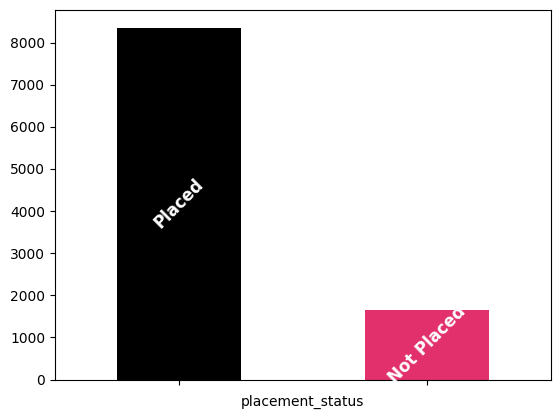

In [4]:
labels = ['Placed', 'Not Placed']
ax = df['placement_status'].value_counts().reindex(labels).plot.bar(color=['black','#E1306C','gray', 'green'])
ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', rotation=45,fontsize=12, fontweight='bold')
ax.set_xticklabels([])
plt.show()

In [5]:
df.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status             str
dtype: object

In [6]:
dfe = df.copy()

dfe['placement_status'] = dfe['placement_status'].map({"Placed" : 0, "Not Placed" : 1})

In [8]:
dfe.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status           int64
dtype: object

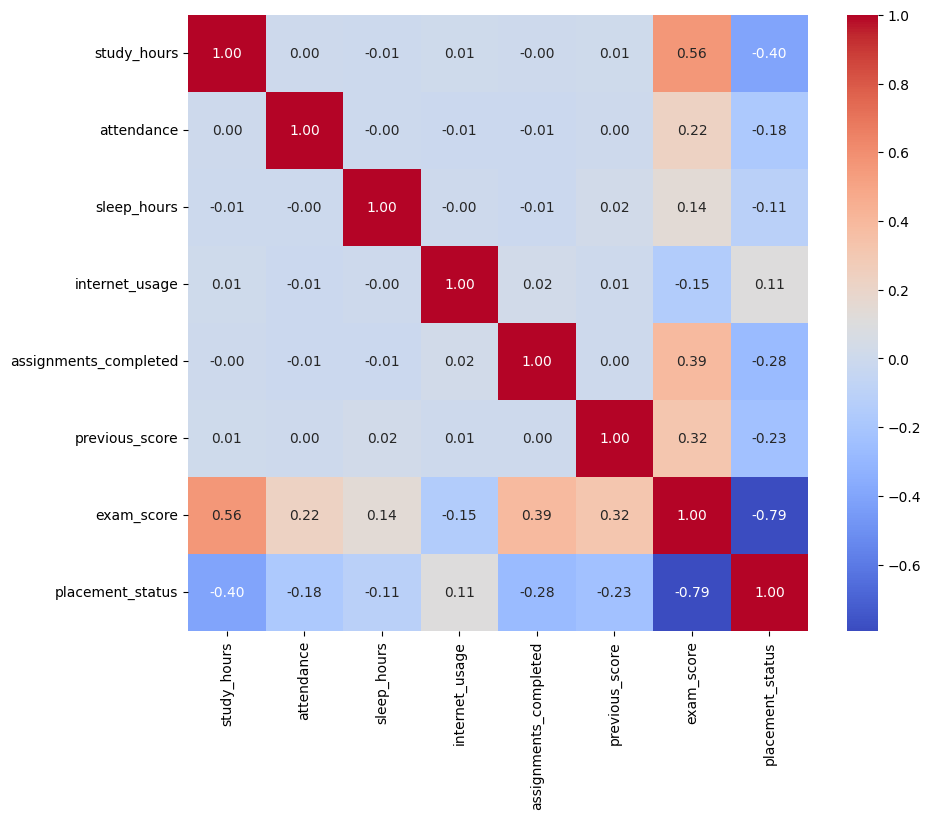

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.show()